<a href="https://colab.research.google.com/github/kukuhagushermawan/deep-learning-assignment-2-learning-strategy/blob/main/Tugas_2_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas 2 Pembelajaran Mesin Mendalam: Learning Strategy pada MNIST

Nama: Kukuh Agus Hermawan  
NIM: 24/533395/PA/22573

Notebook ini berisi replikasi klasifikasi digit MNIST dengan arsitektur fully connected, lalu lima eksperimen pencegahan overfitting: L1, L2, Dropout, Early Stopping, dan L1 + Dropout. Semua skenario memakai arsitektur, optimizer, batch size, dan random seed yang sama, sehingga perbedaan hasil hanya berasal dari teknik yang diuji.

## 1. Persiapan

### 1.1 Import Library

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import absl.logging

import keras
from keras.datasets import mnist
from keras.models import Sequential, load_model
from keras.layers import Flatten, Dense, Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping

absl.logging.set_verbosity(absl.logging.ERROR)
SEED = 42
keras.utils.set_random_seed(SEED)
os.makedirs('hasil', exist_ok=True)
print('Keras versi:', keras.__version__)

Keras versi: 3.13.2


### 1.2 Load dan Preprocessing Data
- MNIST berisi 60.000 gambar training dan 10.000 gambar test, ukuran 28x28 piksel grayscale.
- Reshape ke (28, 28, 1): menambah dimensi channel.
- Normalisasi: nilai piksel 0-255 dibagi 255 menjadi 0-1 agar training stabil.
- One-hot encoding: label 3 menjadi [0,0,0,1,0,0,0,0,0,0] sesuai output softmax 10 kelas.
- Data test juga dipakai sebagai data validasi saat training.

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test :', X_test.shape, '| y_test :', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28, 1) | y_train: (60000, 10)
X_test : (10000, 28, 28, 1) | y_test : (10000, 10)


## 2. Model Baseline

### 2.1 Define Model
- Flatten: mengubah gambar 28x28 menjadi vektor 784 nilai.
- Dense(64, relu): satu hidden layer dengan 64 neuron.
- Dense(10, softmax): 10 neuron output, satu per digit, dalam bentuk probabilitas.

In [ ]:
keras.utils.set_random_seed(SEED)

model1 = Sequential()
model1.add(keras.Input(shape=(28, 28, 1)))
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Param adalah jumlah bobot dan bias yang dicari oleh learning algorithm:
- Flatten: 0 (hanya mengubah bentuk data).
- Dense 64: 784 x 64 bobot + 64 bias = 50.240.
- Dense 10: 64 x 10 bobot + 10 bias = 650.
- Total: 50.890 parameter.

### 2.2 Compile, Fit, Save, dan Evaluate
- Optimizer Adam memakai adaptive learning rate: langkah pembaruan bobot besar saat error masih jauh dari minimum, lalu mengecil sendiri saat mendekati minimum.
- Loss categorical crossentropy dipakai untuk klasifikasi multikelas dengan label one-hot.
- Batch size 100 (mini-batch SGD): bobot diperbarui setiap 100 data, yaitu 600 kali per epoch atau 6.000 kali dalam 10 epoch. Jika diperbarui per satu data, jumlahnya menjadi 60.000 kali per epoch atau 600.000 kali dalam 10 epoch.
- Model disimpan ke file .h5 agar bisa dipakai ulang tanpa training.

In [ ]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

history1 = model1.fit(X_train, y_train, epochs=10, batch_size=100,
                      validation_data=(X_test, y_test))

model1.save('my_model1.h5')
model1.evaluate(X_test, y_test)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.8896 - loss: 0.3959 - val_acc: 0.9371 - val_loss: 0.2226
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9444 - loss: 0.1942 - val_acc: 0.9539 - val_loss: 0.1595
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9582 - loss: 0.1427 - val_acc: 0.9640 - val_loss: 0.1289
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9670 - loss: 0.1138 - val_acc: 0.9674 - val_loss: 0.1126
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9732 - loss: 0.0947 - val_acc: 0.9698 - val_loss: 0.1025
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9774 - loss: 0.0810 - val_acc: 0.9714 - val_loss: 0.0964
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9804 - loss: 0.0707 - val_acc: 0.9720 - val_loss: 0.0926
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9827 - loss: 0.0625 - val_acc: 0.9725 - val_loss: 0.0897
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

[0.08817409723997116, 0.9721999764442444]

### 2.3 Visualisasi Loss
Membandingkan training loss (merah) dan validation loss (biru) per epoch.

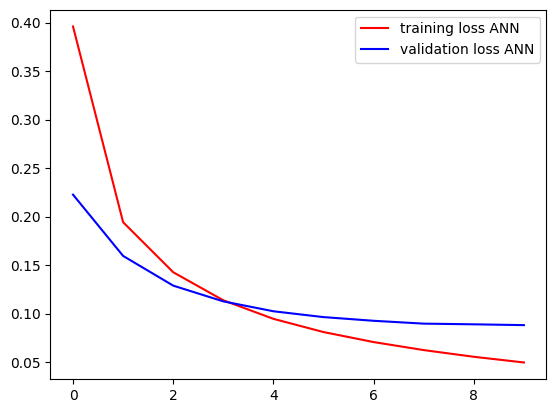

In [ ]:
epochs = range(10)
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']
plt.plot(epochs, loss1, 'r', label='training loss ANN')
plt.plot(epochs, val_loss1, 'b', label='validation loss ANN')
plt.legend()
plt.show()

### 2.4 Load Model dan Prediksi
Model yang tersimpan dimuat ulang untuk memprediksi gambar test ke-30. np.argmax mengambil kelas dengan probabilitas tertinggi.

label actual    : 3
label prediction: 3


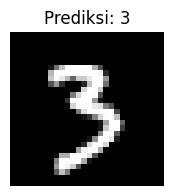

In [ ]:
model_simpan = load_model('my_model1.h5')
pred = model_simpan.predict(X_test, verbose=0)
print('label actual    :', np.argmax(y_test[30]))
print('label prediction:', np.argmax(pred[30]))

plt.figure(figsize=(2, 2))
plt.imshow(X_test[30].reshape(28, 28), cmap='gray')
plt.title(f'Prediksi: {np.argmax(pred[30])}')
plt.axis('off')
plt.show()

## 3. Kerangka Eksperimen

### 3.1 Kondisi Model yang Dianalisis
Kondisi model dibaca dari grafik training loss dan validation loss.

| Kondisi | Ciri pada grafik | Cara mengatasi |
|---|---|---|
| Overfit | Train loss terus turun, val loss berhenti turun lalu naik | Early stopping, regularisasi, dropout, augmentasi data |
| Underfit | Loss train dan val sama-sama masih tinggi | Tambah epoch, modifikasi arsitektur jaringan |
| Best fit | Loss train dan val turun bersama dan mendekati 0 | Model siap dipakai |

### 3.2 Fungsi Bantu
- buat_model(): arsitektur yang sama dengan baseline, dengan opsi L1, L2, dan Dropout.
- jalankan(): menampilkan summary, training, evaluasi, grafik, dan interpretasi.
- interpretasi(): menjelaskan hasil running dan menentukan kondisi model.

Dua ukuran tambahan dipakai agar perbandingan adil:
- Akurasi train diukur ulang dengan evaluate. Akurasi di log training adalah rata-rata selama epoch berjalan dan, pada Dropout, dihitung saat sebagian neuron dimatikan.
- Cross-entropy murni (CE murni). Loss Keras pada model L1/L2 sudah ditambah penalti regularisasi, sehingga loss antarskenario tidak bisa dibandingkan langsung. CE murni menghitung loss tanpa penalti tersebut.

In [ ]:
HASIL = {}

def buat_model(l1=None, l2=None, dropout=None):
    keras.utils.set_random_seed(SEED)
    if l1 and l2:
        reg = regularizers.l1_l2(l1=l1, l2=l2)
    elif l1:
        reg = regularizers.l1(l1)
    elif l2:
        reg = regularizers.l2(l2)
    else:
        reg = None

    model = Sequential()
    model.add(keras.Input(shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(64, activation='relu', kernel_regularizer=reg))
    if dropout:
        model.add(Dropout(dropout))
    model.add(Dense(10, activation='softmax', kernel_regularizer=reg))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    return model


def cross_entropy_murni(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1.0)
    return float(-np.mean(np.sum(y_true * np.log(y_pred), axis=1)))


def plot_history(nama, h, file):
    ep = np.arange(1, len(h['loss']) + 1)
    best = int(np.argmin(h['val_loss'])) + 1
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

    ax[0].plot(ep, h['loss'], 'r-o', ms=3, label='Training loss')
    ax[0].plot(ep, h['val_loss'], 'b-o', ms=3, label='Validation loss')
    ax[0].axvline(best, color='gray', ls='--', lw=1, label=f'Val loss min (epoch {best})')
    ax[0].set_title(f'Loss: {nama}')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend(); ax[0].grid(alpha=.3)

    ax[1].plot(ep, h['acc'], 'r-o', ms=3, label='Training acc')
    ax[1].plot(ep, h['val_acc'], 'b-o', ms=3, label='Validation acc')
    ax[1].set_title(f'Akurasi: {nama}')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Akurasi'); ax[1].legend(); ax[1].grid(alpha=.3)

    plt.tight_layout()
    plt.savefig(f'hasil/{file}.png', dpi=150, bbox_inches='tight')
    plt.show()


def tentukan_kondisi(nama):
    r, h = HASIL[nama], HASIL[nama]['history']
    vl, tl = np.array(h['val_loss']), np.array(h['loss'])
    n, best = len(vl), int(np.argmin(vl)) + 1

    if best < n and r.get('early_stop'):
        return 'Dihentikan sebelum overfit', (f'Val loss terendah di epoch {best}, lalu naik sementara train loss '
                                              f'terus turun ({tl[best-1]:.4f} ke {tl[-1]:.4f}). Training berhenti di '
                                              f'epoch {n} dan model memakai bobot epoch {best}.')
    if best < n:
        return 'Overfit', (f'Val loss terendah di epoch {best}, lalu naik sementara train loss '
                           f'terus turun ({tl[best-1]:.4f} ke {tl[-1]:.4f}).')
    if 'Baseline' in HASIL and nama != 'Baseline' and r['train_acc'] < HASIL['Baseline']['train_acc'] - 0.01:
        return 'Cenderung underfit', ('Akurasi train turun lebih dari 1 poin dari baseline: '
                                      'regularisasi terlalu menekan kemampuan model mempelajari data.')
    turun_val = (vl[-2] - vl[-1]) / vl[-2] * 100
    turun_train = (tl[-2] - tl[-1]) / tl[-2] * 100
    if turun_val < 1 and turun_train > 5:
        return 'Di ambang overfit', (f'Di epoch terakhir val loss hanya turun {turun_val:.1f}%, '
                                     f'sedangkan train loss masih turun {turun_train:.1f}%.')
    return 'Best fit', 'Train loss dan val loss turun bersama dengan selisih kecil.'


def interpretasi(nama):
    r = HASIL[nama]
    gap = (r['train_acc'] - r['test_acc']) * 100
    kondisi, alasan = tentukan_kondisi(nama)
    r['kondisi'] = kondisi

    print(f'\n=== Interpretasi: {nama} ===')
    print(f'Akurasi train {r["train_acc"]:.4f} | akurasi test {r["test_acc"]:.4f} | '
          f'gap {gap:.2f} poin | CE murni {r["ce_murni"]:.4f}')
    print(f'Kondisi: {kondisi}. {alasan}')

    if 'Baseline' in HASIL and nama != 'Baseline':
        b = HASIL['Baseline']
        d_acc = (r['test_acc'] - b['test_acc']) * 100
        d_gap = gap - (b['train_acc'] - b['test_acc']) * 100
        if abs(d_acc) < 0.005:
            teks_acc = 'akurasi test sama'
        else:
            teks_acc = f'akurasi test {"naik" if d_acc > 0 else "turun"} {abs(d_acc):.2f} poin'
        if abs(d_gap) < 0.005:
            teks_gap = 'gap sama'
        else:
            teks_gap = f'gap {"menyempit" if d_gap < 0 else "melebar"} {abs(d_gap):.2f} poin'
        print(f'Dibanding baseline: {teks_acc}, {teks_gap}, CE murni {r["ce_murni"] - b["ce_murni"]:+.4f}.')


def jalankan(nama, model, file, epochs=10, callbacks=None):
    model.summary()
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=100,
                        validation_data=(X_test, y_test),
                        callbacks=callbacks, verbose=2)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    _, train_acc = model.evaluate(X_train, y_train, verbose=0)
    pred = model.predict(X_test, verbose=0)

    HASIL[nama] = dict(history=history.history, test_acc=test_acc, test_loss=test_loss,
                       train_acc=train_acc, ce_murni=cross_entropy_murni(y_test, pred),
                       params=model.count_params(), epoch_jalan=len(history.history['loss']),
                       early_stop=bool(callbacks))
    plot_history(nama, history.history, file)
    interpretasi(nama)
    return model, history

### 3.3 Baseline sebagai Pembanding
Baseline dijalankan ulang lewat fungsi yang sama agar metriknya setara dengan semua eksperimen.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 4s - 7ms/step - acc: 0.8896 - loss: 0.3959 - val_acc: 0.9371 - val_loss: 0.2226
Epoch 2/10
600/600 - 2s - 3ms/step - acc: 0.9444 - loss: 0.1942 - val_acc: 0.9539 - val_loss: 0.1595
Epoch 3/10
600/600 - 2s - 3ms/step - acc: 0.9582 - loss: 0.1427 - val_acc: 0.9640 - val_loss: 0.1289
Epoch 4/10
600/600 - 2s - 3ms/step - acc: 0.9670 - loss: 0.1138 - val_acc: 0.9674 - val_loss: 0.1126
Epoch 5/10
600/600 - 2s - 3ms/step - acc: 0.9732 - loss: 0.0947 - val_acc: 0.9698 - val_loss: 0.1025
Epoch 6/10
600/600 - 2s - 3ms/step - acc: 0.9774 - loss: 0.0810 - val_acc: 0.9714 - val_loss: 0.0964
Epoch 7/10
600/600 - 2s - 4ms/step - acc: 0.9804 - loss: 0.0707 - val_acc: 0.9720 - val_loss: 0.0926
Epoch 8/10
600/600 - 2s - 3ms/step - acc: 0.9827 - loss: 0.0625 - val_acc: 0.9725 - val_loss: 0.0897
Epoch 9/10
600/600 - 2s - 3ms/step - acc: 0.9844 - loss: 0.0556 - val_acc: 0.9723 - val_loss: 0.0890
Epoch 10/10
600/600 - 2s - 3ms/step - acc: 0.9862 - loss: 0.0497 - val_acc: 0.9722 - val_lo

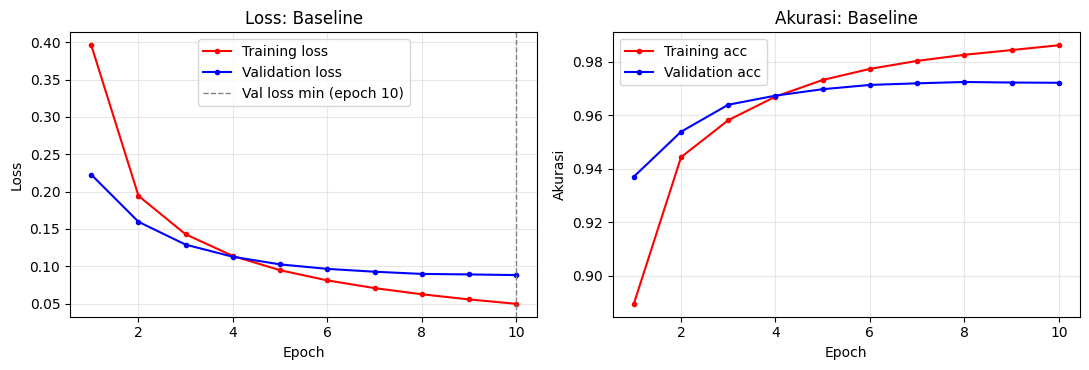


=== Interpretasi: Baseline ===
Akurasi train 0.9868 | akurasi test 0.9722 | gap 1.46 poin | CE murni 0.0882
Kondisi: Di ambang overfit. Di epoch terakhir val loss hanya turun 0.9%, sedangkan train loss masih turun 10.6%.


In [ ]:
model_base, hist_base = jalankan('Baseline', buat_model(), 'baseline')

## 4. Eksperimen 2(a): Regularisasi L1

L1 (LASSO) menambahkan penalti λ x Σ|w| ke fungsi loss. Bobot yang tidak berkontribusi bisa ditekan sampai bernilai 0, sehingga model lebih sederhana dan sekaligus menyeleksi fitur.

Rate: λ = 0.0001. Hidden layer memiliki 50.176 bobot dengan total |w| awal sekitar 2.000, sehingga penalti awal sekitar 0,2. Nilai ini sebanding dengan cross-entropy tanpa mendominasinya.

Regularisasi tidak mengubah jumlah parameter pada summary, hanya cara bobot diperbarui.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 4s - 6ms/step - acc: 0.8901 - loss: 0.5386 - val_acc: 0.9355 - val_loss: 0.3541
Epoch 2/10
600/600 - 2s - 3ms/step - acc: 0.9411 - loss: 0.3300 - val_acc: 0.9492 - val_loss: 0.2904
Epoch 3/10
600/600 - 2s - 3ms/step - acc: 0.9538 - loss: 0.2795 - val_acc: 0.9585 - val_loss: 0.2561
Epoch 4/10
600/600 - 2s - 3ms/step - acc: 0.9606 - loss: 0.2509 - val_acc: 0.9631 - val_loss: 0.2363
Epoch 5/10
600/600 - 2s - 3ms/step - acc: 0.9648 - loss: 0.2327 - val_acc: 0.9659 - val_loss: 0.2241
Epoch 6/10
600/600 - 2s - 4ms/step - acc: 0.9681 - loss: 0.2200 - val_acc: 0.9679 - val_loss: 0.2145
Epoch 7/10
600/600 - 2s - 3ms/step - acc: 0.9704 - loss: 0.2103 - val_acc: 0.9694 - val_loss: 0.2077
Epoch 8/10
600/600 - 2s - 3ms/step - acc: 0.9723 - loss: 0.2026 - val_acc: 0.9709 - val_loss: 0.2021
Epoch 9/10
600/600 - 2s - 3ms/step - acc: 0.9738 - loss: 0.1963 - val_acc: 0.9728 - val_loss: 0.1979
Epoch 10/10
600/600 - 2s - 3ms/step - acc: 0.9749 - loss: 0.1912 - val_acc: 0.9731 - val_lo

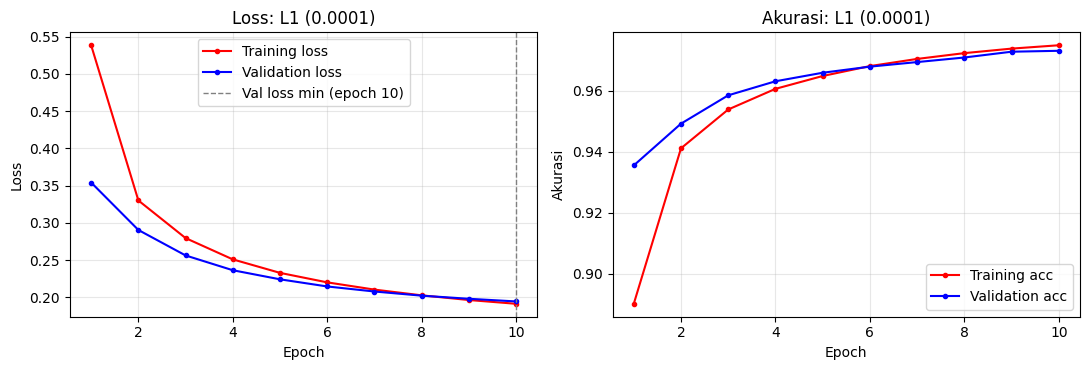


=== Interpretasi: L1 (0.0001) ===
Akurasi train 0.9778 | akurasi test 0.9731 | gap 0.47 poin | CE murni 0.0936
Kondisi: Best fit. Train loss dan val loss turun bersama dengan selisih kecil.
Dibanding baseline: akurasi test naik 0.09 poin, gap menyempit 0.99 poin, CE murni +0.0054.


In [ ]:
L1_RATE = 1e-4
model_l1, hist_l1 = jalankan(f'L1 ({L1_RATE})', buat_model(l1=L1_RATE), '2a_l1')

In [ ]:
# Persentase bobot hidden layer yang hampir nol (|w| < 0.001)
w_base = model_base.layers[1].get_weights()[0]
w_l1 = model_l1.layers[1].get_weights()[0]
print(f'Baseline: {np.mean(np.abs(w_base) < 1e-3)*100:.1f}% bobot hampir nol')
print(f'L1      : {np.mean(np.abs(w_l1) < 1e-3)*100:.1f}% bobot hampir nol')

Baseline: 0.7% bobot hampir nol
L1      : 49.6% bobot hampir nol


## 5. Eksperimen 2(b): Regularisasi L2

L2 (Ridge) menambahkan penalti λ x Σw² ke fungsi loss. Karena dikuadratkan, bobot mengecil mendekati 0 tetapi tidak sampai 0. L2 lebih hati-hati: bobot diperkecil merata, tidak dihapus.

Rate: λ = 0.001. Nilai w² jauh lebih kecil dari |w|, sehingga rate dibuat 10 kali lebih besar dari L1 agar skala penaltinya setara (sekitar 0,1 di awal training).

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 3s - 6ms/step - acc: 0.8893 - loss: 0.5081 - val_acc: 0.9347 - val_loss: 0.3387
Epoch 2/10
600/600 - 2s - 3ms/step - acc: 0.9399 - loss: 0.3229 - val_acc: 0.9465 - val_loss: 0.2905
Epoch 3/10
600/600 - 2s - 4ms/step - acc: 0.9507 - loss: 0.2883 - val_acc: 0.9555 - val_loss: 0.2691
Epoch 4/10
600/600 - 2s - 3ms/step - acc: 0.9560 - loss: 0.2713 - val_acc: 0.9596 - val_loss: 0.2586
Epoch 5/10
600/600 - 2s - 3ms/step - acc: 0.9599 - loss: 0.2618 - val_acc: 0.9622 - val_loss: 0.2528
Epoch 6/10
600/600 - 2s - 3ms/step - acc: 0.9623 - loss: 0.2561 - val_acc: 0.9640 - val_loss: 0.2493
Epoch 7/10
600/600 - 2s - 3ms/step - acc: 0.9639 - loss: 0.2524 - val_acc: 0.9638 - val_loss: 0.2473
Epoch 8/10
600/600 - 2s - 3ms/step - acc: 0.9653 - loss: 0.2497 - val_acc: 0.9643 - val_loss: 0.2453
Epoch 9/10
600/600 - 2s - 3ms/step - acc: 0.9662 - loss: 0.2476 - val_acc: 0.9660 - val_loss: 0.2436
Epoch 10/10
600/600 - 2s - 4ms/step - acc: 0.9669 - loss: 0.2460 - val_acc: 0.9665 - val_lo

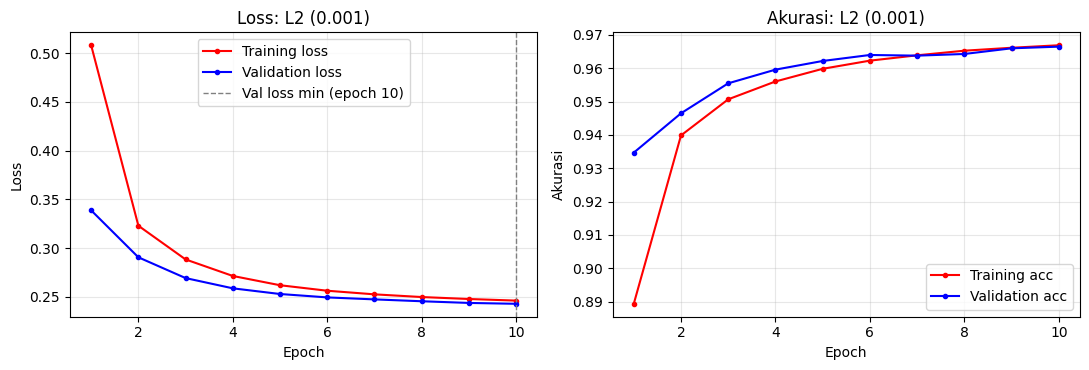


=== Interpretasi: L2 (0.001) ===
Akurasi train 0.9700 | akurasi test 0.9665 | gap 0.35 poin | CE murni 0.1242
Kondisi: Cenderung underfit. Akurasi train turun lebih dari 1 poin dari baseline: regularisasi terlalu menekan kemampuan model mempelajari data.
Dibanding baseline: akurasi test turun 0.57 poin, gap menyempit 1.11 poin, CE murni +0.0361.


In [ ]:
L2_RATE = 1e-3
model_l2, hist_l2 = jalankan(f'L2 ({L2_RATE})', buat_model(l2=L2_RATE), '2b_l2')

In [ ]:
# Perbandingan besar bobot hidden layer
w_l2 = model_l2.layers[1].get_weights()[0]
print(f'Rata-rata |w|  Baseline: {np.mean(np.abs(w_base)):.4f} | L1: {np.mean(np.abs(w_l1)):.4f} | L2: {np.mean(np.abs(w_l2)):.4f}')
print(f'Bobot hampir nol  L1: {np.mean(np.abs(w_l1) < 1e-3)*100:.1f}% | L2: {np.mean(np.abs(w_l2) < 1e-3)*100:.1f}%')

Rata-rata |w|  Baseline: 0.0984 | L1: 0.0161 | L2: 0.0210
Bobot hampir nol  L1: 49.6% | L2: 27.8%


## 6. Eksperimen 2(c): Dropout

Dropout mematikan p% neuron hidden layer secara acak di setiap langkah training. Model tidak bisa bergantung pada neuron tertentu, sehingga decision boundary tidak terlalu ketat mengikuti data training. Saat evaluasi dan prediksi, dropout otomatis nonaktif.

Rate: p = 10%, sekitar 6 dari 64 neuron dimatikan setiap langkah.

Pada summary muncul layer Dropout dengan 0 parameter. Pada grafik, akurasi training bisa lebih rendah dari validation karena dihitung saat sebagian neuron sedang dimatikan.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 5s - 8ms/step - acc: 0.8784 - loss: 0.4291 - val_acc: 0.9403 - val_loss: 0.2121
Epoch 2/10
600/600 - 2s - 3ms/step - acc: 0.9386 - loss: 0.2117 - val_acc: 0.9537 - val_loss: 0.1582
Epoch 3/10
600/600 - 2s - 3ms/step - acc: 0.9518 - loss: 0.1653 - val_acc: 0.9597 - val_loss: 0.1314
Epoch 4/10
600/600 - 2s - 3ms/step - acc: 0.9587 - loss: 0.1375 - val_acc: 0.9634 - val_loss: 0.1169
Epoch 5/10
600/600 - 2s - 3ms/step - acc: 0.9653 - loss: 0.1179 - val_acc: 0.9674 - val_loss: 0.1066
Epoch 6/10
600/600 - 2s - 3ms/step - acc: 0.9691 - loss: 0.1042 - val_acc: 0.9703 - val_loss: 0.0981
Epoch 7/10
600/600 - 2s - 3ms/step - acc: 0.9718 - loss: 0.0936 - val_acc: 0.9726 - val_loss: 0.0930
Epoch 8/10
600/600 - 3s - 4ms/step - acc: 0.9744 - loss: 0.0842 - val_acc: 0.9731 - val_loss: 0.0898
Epoch 9/10
600/600 - 2s - 3ms/step - acc: 0.9768 - loss: 0.0765 - val_acc: 0.9741 - val_loss: 0.0883
Epoch 10/10
600/600 - 2s - 3ms/step - acc: 0.9774 - loss: 0.0719 - val_acc: 0.9748 - val_lo

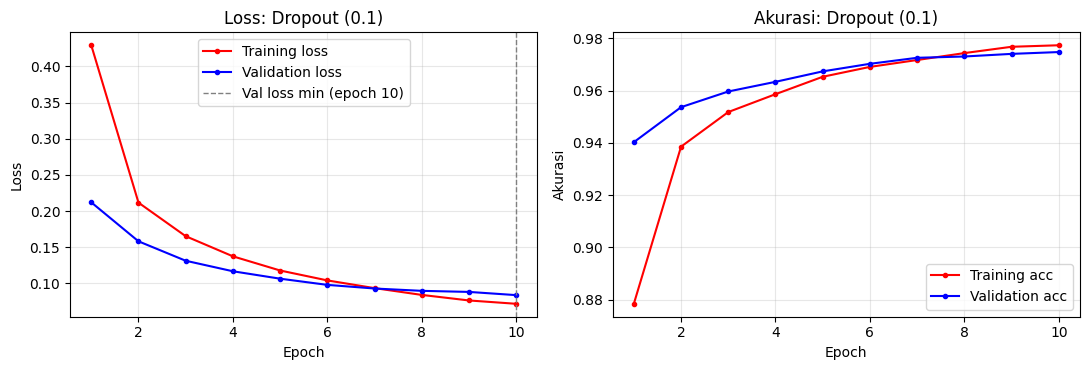


=== Interpretasi: Dropout (0.1) ===
Akurasi train 0.9879 | akurasi test 0.9748 | gap 1.31 poin | CE murni 0.0839
Kondisi: Best fit. Train loss dan val loss turun bersama dengan selisih kecil.
Dibanding baseline: akurasi test naik 0.26 poin, gap menyempit 0.15 poin, CE murni -0.0043.


In [ ]:
DROPOUT_RATE = 0.1
model_do, hist_do = jalankan(f'Dropout ({DROPOUT_RATE})', buat_model(dropout=DROPOUT_RATE), '2c_dropout')

## 7. Eksperimen 2(d): Early Stopping

Early stopping menghentikan training saat validation loss berhenti membaik, lalu memakai model sebelum overfit.
- monitor='val_loss': metrik yang dipantau.
- patience=3: berhenti jika 3 epoch berturut-turut tidak ada perbaikan.
- restore_best_weights=True: bobot dikembalikan ke epoch terbaik.

Batas epoch dinaikkan menjadi 50. Jika tetap 10, training selesai sebelum early stopping sempat bekerja.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
600/600 - 3s - 5ms/step - acc: 0.8896 - loss: 0.3959 - val_acc: 0.9371 - val_loss: 0.2226
Epoch 2/50
600/600 - 2s - 3ms/step - acc: 0.9444 - loss: 0.1942 - val_acc: 0.9539 - val_loss: 0.1595
Epoch 3/50
600/600 - 2s - 3ms/step - acc: 0.9582 - loss: 0.1427 - val_acc: 0.9640 - val_loss: 0.1289
Epoch 4/50
600/600 - 2s - 3ms/step - acc: 0.9670 - loss: 0.1138 - val_acc: 0.9674 - val_loss: 0.1126
Epoch 5/50
600/600 - 2s - 3ms/step - acc: 0.9732 - loss: 0.0947 - val_acc: 0.9698 - val_loss: 0.1025
Epoch 6/50
600/600 - 3s - 4ms/step - acc: 0.9774 - loss: 0.0810 - val_acc: 0.9714 - val_loss: 0.0964
Epoch 7/50
600/600 - 2s - 3ms/step - acc: 0.9804 - loss: 0.0707 - val_acc: 0.9720 - val_loss: 0.0926
Epoch 8/50
600/600 - 2s - 3ms/step - acc: 0.9827 - loss: 0.0625 - val_acc: 0.9725 - val_loss: 0.0897
Epoch 9/50
600/600 - 2s - 3ms/step - acc: 0.9844 - loss: 0.0556 - val_acc: 0.9723 - val_loss: 0.0890
Epoch 10/50
600/600 - 2s - 3ms/step - acc: 0.9862 - loss: 0.0497 - val_acc: 0.9722 - val_lo

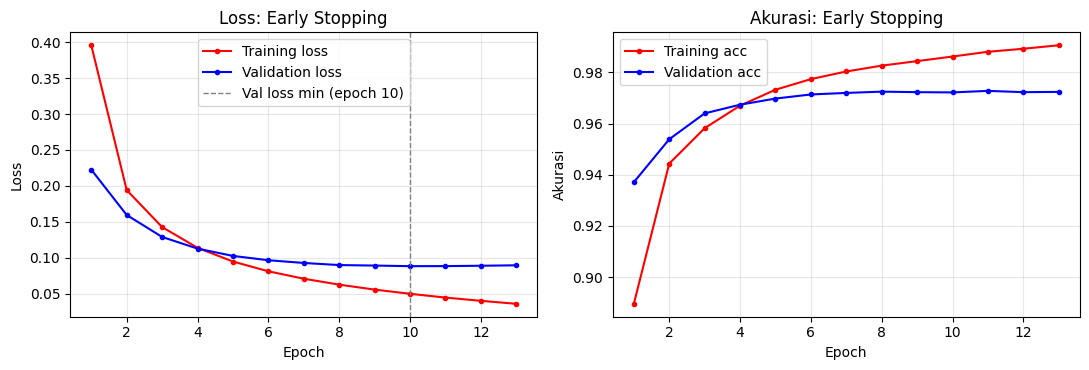


=== Interpretasi: Early Stopping ===
Akurasi train 0.9868 | akurasi test 0.9722 | gap 1.46 poin | CE murni 0.0882
Kondisi: Dihentikan sebelum overfit. Val loss terendah di epoch 10, lalu naik sementara train loss terus turun (0.0497 ke 0.0358). Training berhenti di epoch 13 dan model memakai bobot epoch 10.
Dibanding baseline: akurasi test sama, gap sama, CE murni +0.0000.


In [ ]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
model_es, hist_es = jalankan('Early Stopping', buat_model(), '2d_early_stopping',
                             epochs=50, callbacks=[es])

## 8. Eksperimen 2(e): L1 + Dropout

Menggabungkan dua mekanisme yang bekerja di tempat berbeda: L1 menekan bobot melalui fungsi loss, Dropout mematikan neuron saat training. Rate sama dengan eksperimen 2(a) dan 2(c) agar efek kombinasinya bisa dibandingkan langsung.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 5s - 8ms/step - acc: 0.8771 - loss: 0.5775 - val_acc: 0.9359 - val_loss: 0.3519
Epoch 2/10
600/600 - 2s - 3ms/step - acc: 0.9340 - loss: 0.3557 - val_acc: 0.9511 - val_loss: 0.2937
Epoch 3/10
600/600 - 2s - 3ms/step - acc: 0.9459 - loss: 0.3093 - val_acc: 0.9578 - val_loss: 0.2624
Epoch 4/10
600/600 - 2s - 3ms/step - acc: 0.9520 - loss: 0.2825 - val_acc: 0.9624 - val_loss: 0.2435
Epoch 5/10
600/600 - 2s - 3ms/step - acc: 0.9571 - loss: 0.2640 - val_acc: 0.9655 - val_loss: 0.2289
Epoch 6/10
600/600 - 2s - 4ms/step - acc: 0.9604 - loss: 0.2516 - val_acc: 0.9682 - val_loss: 0.2224
Epoch 7/10
600/600 - 2s - 3ms/step - acc: 0.9621 - loss: 0.2415 - val_acc: 0.9698 - val_loss: 0.2135
Epoch 8/10
600/600 - 2s - 3ms/step - acc: 0.9646 - loss: 0.2328 - val_acc: 0.9713 - val_loss: 0.2093
Epoch 9/10
600/600 - 2s - 3ms/step - acc: 0.9664 - loss: 0.2265 - val_acc: 0.9711 - val_loss: 0.2045
Epoch 10/10
600/600 - 2s - 3ms/step - acc: 0.9674 - loss: 0.2229 - val_acc: 0.9719 - val_lo

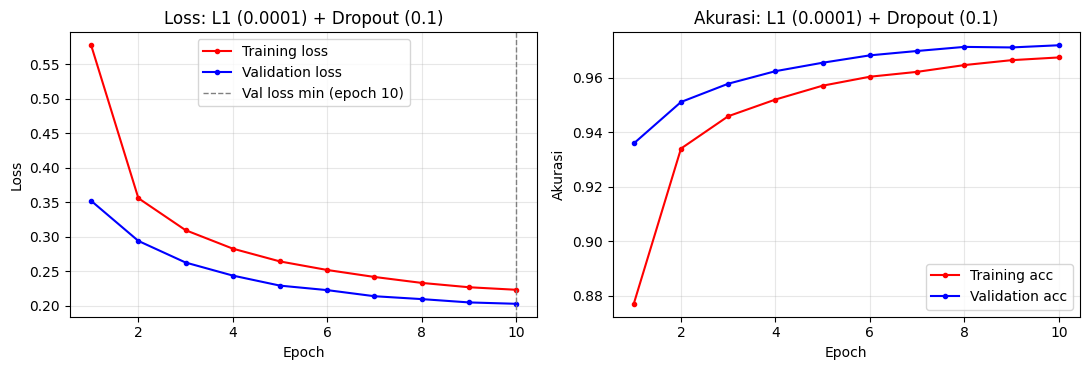


=== Interpretasi: L1 (0.0001) + Dropout (0.1) ===
Akurasi train 0.9789 | akurasi test 0.9719 | gap 0.70 poin | CE murni 0.0927
Kondisi: Best fit. Train loss dan val loss turun bersama dengan selisih kecil.
Dibanding baseline: akurasi test turun 0.03 poin, gap menyempit 0.77 poin, CE murni +0.0046.


In [ ]:
model_l1do, hist_l1do = jalankan(f'L1 ({L1_RATE}) + Dropout ({DROPOUT_RATE})',
                                 buat_model(l1=L1_RATE, dropout=DROPOUT_RATE), '2e_l1_dropout')

## 9. Perbandingan Semua Skenario

Kolom yang paling penting:
- Akurasi test: kinerja pada data baru.
- Gap: selisih akurasi train dan test. Makin kecil, makin baik generalisasinya.
- CE murni: angka kesalahan prediksi yang bisa dibandingkan adil antarskenario.

In [ ]:
rows = []
for nama, r in HASIL.items():
    rows.append({
        'Skenario': nama,
        'Epoch': r['epoch_jalan'],
        'Parameter': r['params'],
        'Akurasi train': round(r['train_acc'], 4),
        'Akurasi test': round(r['test_acc'], 4),
        'Gap (poin %)': round((r['train_acc'] - r['test_acc']) * 100, 2),
        'Loss test (Keras)': round(r['test_loss'], 4),
        'CE murni': round(r['ce_murni'], 4),
        'Kondisi': r['kondisi'],
    })
ringkasan = pd.DataFrame(rows)
ringkasan.to_csv('hasil/ringkasan.csv', index=False)
ringkasan

,Skenario,Epoch,Parameter,Akurasi train,Akurasi test,Gap (poin %),Loss test (Keras),CE murni,Kondisi
0,Baseline,10,50890,0.9868,0.9722,1.46,0.0882,0.0882,Di ambang overfit
1,L1 (0.0001),10,50890,0.9778,0.9731,0.47,0.1944,0.0936,Best fit
2,L2 (0.001),10,50890,0.9700,0.9665,0.35,0.2427,0.1242,Cenderung underfit
3,Dropout (0.1),10,50890,0.9879,0.9748,1.31,0.0839,0.0839,Best fit
4,Early Stopping,13,50890,0.9868,0.9722,1.46,0.0882,0.0882,Dihentikan sebelum overfit
5,L1 (0.0001) + Dropout (0.1),10,50890,0.9789,0.9719,0.70,0.2025,0.0927,Best fit


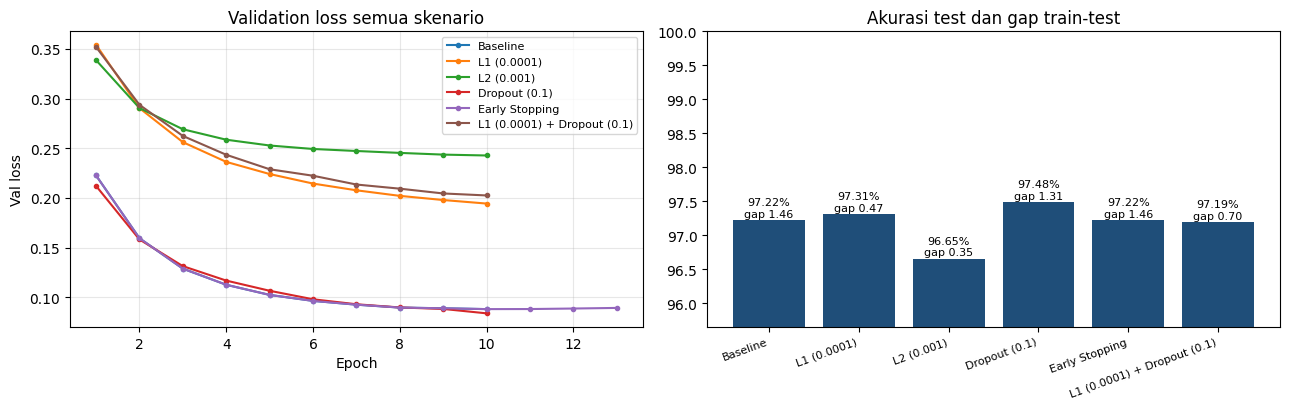

Akurasi test tertinggi : Dropout (0.1) (0.9748)
Gap train-test terkecil: L2 (0.001) (0.35 poin)


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

for nama, r in HASIL.items():
    vl = r['history']['val_loss']
    ax[0].plot(range(1, len(vl) + 1), vl, '-o', ms=3, label=nama)
ax[0].set_title('Validation loss semua skenario')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Val loss'); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8)

nama_list = list(HASIL.keys())
acc = [HASIL[n]['test_acc'] * 100 for n in nama_list]
gap = [(HASIL[n]['train_acc'] - HASIL[n]['test_acc']) * 100 for n in nama_list]
x = np.arange(len(nama_list))
bars = ax[1].bar(x, acc, color='#1f4e79')
for b, v, g in zip(bars, acc, gap):
    ax[1].text(b.get_x() + b.get_width() / 2, v + 0.05, f'{v:.2f}%\ngap {g:.2f}', ha='center', fontsize=8)
ax[1].set_xticks(x); ax[1].set_xticklabels(nama_list, rotation=20, ha='right', fontsize=8)
ax[1].set_ylim(min(acc) - 1, 100)
ax[1].set_title('Akurasi test dan gap train-test')

plt.tight_layout()
plt.savefig('hasil/perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

terbaik = max(HASIL, key=lambda n: HASIL[n]['test_acc'])
gap_kecil = min(HASIL, key=lambda n: HASIL[n]['train_acc'] - HASIL[n]['test_acc'])
print(f'Akurasi test tertinggi : {terbaik} ({HASIL[terbaik]["test_acc"]:.4f})')
print(f'Gap train-test terkecil: {gap_kecil} '
      f'({(HASIL[gap_kecil]["train_acc"] - HASIL[gap_kecil]["test_acc"])*100:.2f} poin)')